In [1]:
import numpy as np
import time
import random
import torch
from collections import namedtuple
import matplotlib.pyplot as plt

In [2]:
n_actions = 4
device = "mps:0"
obs_size = (3, 9, 9)
gamma = 0.99
lr = 1e-3
TAU = 0.005
n_ep = 2000
batch_size = 1024
loss_fun = torch.nn.MSELoss() # torch.nn.SmoothL1Loss()

In [9]:
Transition = namedtuple("Transition", ("obs", "action", "next_obs", "reward"))

def get_action_ind(mdp_action, mon_action, n_mdp_actions: int = 4) -> int:
    """convert a dictionary of MDP and Monitor actions to an index"""
    return mon_action * n_mdp_actions + mdp_action
    
def process_batch(batch, remove_nan: bool = False):
    batch = Transition(*zip(*batch))
    real_reward_mask = [not np.isnan(p) for p in [r["mdp"] for r in batch.reward]]
    if len(real_reward_mask) == 0:
        raise ValueError("All nan")
    real_reward_idx = [i for i, x in enumerate(real_reward_mask) if x]
    non_final_mask = torch.tensor(tuple(map(lambda s: s["mdp"] is not None, batch.next_obs)), dtype=torch.bool)
    non_final_next_states = torch.tensor(
        np.array([s["mdp"] for s in batch.next_obs if s["mdp"] is not None]), device=device, dtype=torch.float,
    )
    
    mdp_obs = torch.tensor(np.array([state["mdp"] for state in batch.obs]), device=device, dtype=torch.float)
    mon_obs = torch.tensor(np.array([state["monitor"] for state in batch.obs]), device=device, dtype=torch.float)


    mdp_reward = torch.tensor(np.array([reward["mdp"] for reward in batch.reward]), device=device, dtype=torch.float)
    mon_reward = torch.tensor(np.array([reward["monitor"] for reward in batch.reward]), device=device, dtype=torch.float)

    mdp_action = torch.tensor(np.array([a["mdp"] for a in batch.action]), device=device)
    mon_action = torch.tensor(np.array([a["monitor"] for a in batch.action]), device=device)

    process_batch = {
        "real_reward_idx": real_reward_idx,
        "mdp_obs": mdp_obs,
        "mon_obs": mon_obs.unsqueeze(1),
        "non_final_mask": non_final_mask,
        "non_final_next_states": non_final_next_states,
        "mdp_reward": mdp_reward.unsqueeze(1),
        "mon_reward": mon_reward.unsqueeze(1),
        "mdp_action": mdp_action.unsqueeze(1),
        "mon_action": mon_action.unsqueeze(1),
    }
    return process_batch

def dqn_network(n_actions: int, device: str):
    return torch.nn.Sequential(
                torch.nn.Conv2d(obs_size[0], 8, 3),
                torch.nn.ReLU(),
                torch.nn.Conv2d(8, 4, 3),
                torch.nn.ReLU(),
                torch.nn.Flatten(),
                torch.nn.Linear(100, 64),
                torch.nn.ReLU(),
                torch.nn.Linear(64, n_actions),
    ).to(device)

def optimize_policy_model(
    policy_net, target_net, optimizer, loss_fun, mdp_obs, mdp_action, mdp_reward, non_final_next_states, non_final_mask,
):
    q_values = policy_net(mdp_obs).gather(1, mdp_action)
    next_q_values = torch.zeros(mdp_obs.shape[0], device=device)
    with torch.no_grad():
        next_q_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    expected_q_values = (gamma * next_q_values.unsqueeze(1)) + mdp_reward
    loss = loss_fun(q_values, expected_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

def optimize_mon_policy_model(
    policy_net, target_net, optimizer, loss_fun, mdp_obs, mdp_action, mon_action, mdp_reward, mon_reward, non_final_next_states, non_final_mask,
):
    combined_action = get_action_ind(mdp_action, mon_action)
    combined_reward = mdp_reward + mon_reward
    q_values = policy_net(mdp_obs).gather(1, combined_action)
    next_q_values = torch.zeros(mdp_obs.shape[0], device=device)
    with torch.no_grad():
        next_q_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    expected_q_values = (gamma * next_q_values.unsqueeze(1)) + combined_reward
    loss = loss_fun(q_values, expected_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

# Mon-MDP

In [19]:
mon_policy_net = dqn_network(8, device)
mon_target_net = dqn_network(8, device)
mon_optimizer = torch.optim.Adam(mon_policy_net.parameters(), lr=lr)
mon_buffer = np.load("../models/9_9/Penalty/reward_model/env_0.0/eps_1.0/q_lr_1.0/reward_lr_1.0/replay_buffer.npy", allow_pickle=True)[()]

In [20]:
# log_dir = "../models/9_9/Penalty/q_learning/env_0.0/eps_1.0/q_lr_0.001/reward_lr_0.001/"
# reward_net = torch.load(log_dir + "/reward_network_best")
# mon_policy_net = torch.load(log_dir + "/mon_policy_network_best")

In [21]:
mon_loss_list = []
for ep in range(n_ep):
    batch = process_batch(random.sample(list(mon_buffer), batch_size))
    real_reward_idx = batch["real_reward_idx"]
    pred_mdp_reward = reward_net(batch["mdp_obs"]).detach().gather(1, batch["mdp_action"])

    
    ep_loss = optimize_mon_policy_model(
        mon_policy_net, mon_target_net, mon_optimizer, loss_fun, batch["mdp_obs"], batch["mdp_action"], batch["mon_action"], pred_mdp_reward, batch["mon_reward"], batch["non_final_next_states"], batch["non_final_mask"],
    )

    mon_loss_list.append(ep_loss)


    target_net_state_dict = mon_target_net.state_dict()
    policy_net_state_dict = mon_policy_net.state_dict()
    for key in policy_net_state_dict:
        target_net_state_dict[key] = policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
    mon_target_net.load_state_dict(target_net_state_dict)

    # print("loss = {:.3f}".format(ep_loss))

NameError: name 'reward_net' is not defined

In [36]:
t = 10
print("Q-values", mon_policy_net(batch["mdp_obs"][t].unsqueeze(0)).cpu())
print("Reward", reward_net(batch["mdp_obs"][t].unsqueeze(0)).cpu())
batch["mdp_obs"][t][0], pred_mdp_reward[t].item(), batch["mon_reward"][t].item(), batch["mdp_action"][t].item(), batch["mon_action"][t].item()

Q-values tensor([[ 0.4193,  0.3760, -9.2590,  0.3905,  0.2246,  0.1540, -9.4596,  0.1650]],
       grad_fn=<ToCopyBackward0>)
Reward tensor([[ 3.2273e-02, -2.3499e-02, -1.0017e+01, -8.1649e-03]],
       grad_fn=<ToCopyBackward0>)


(tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0'),
 -10.01740837097168,
 -0.20000000298023224,
 2,
 1)

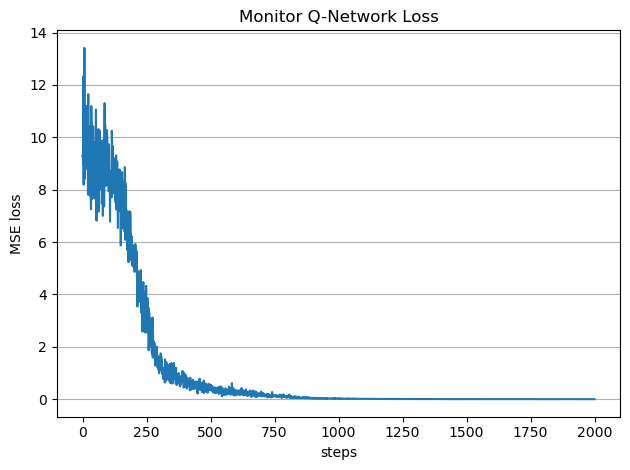

In [9]:
plt.plot(mon_loss_list)
plt.xlabel("steps")
plt.ylabel("MSE loss")
plt.grid(axis="y")
plt.title("Monitor Q-Network Loss")
plt.tight_layout()

In [41]:
p = 2#indx_non[0]
print(mdp_obs[p, 0])
mon_policy_net(mdp_obs[p].unsqueeze(0)).cpu()

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')


tensor([[ 0.6493, -0.1111,  0.8780, -0.7656,  0.5397,  0.6242,  0.5053,  0.6510]],
       grad_fn=<ToCopyBackward0>)

# MDP

In [6]:
policy_net = dqn_network(4, device)
target_net = dqn_network(4, device)
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
mdp_buffer = np.load("../models/9_9/Penalty/q_learning/env_0.0/eps_1.0/q_lr_1.0/reward_lr_1.0/replay_buffer.npy", allow_pickle=True)[()]

In [10]:
loss_list = []

for ep in range(n_ep):
    batch = process_batch(random.sample(list(mdp_buffer), batch_size), device)
    ep_loss = optimize_policy_model(
        policy_net, target_net, optimizer, loss_fun, batch["mdp_obs"], batch["mdp_action"], batch["mdp_reward"], batch["non_final_next_states"], batch["non_final_mask"],
    )

    loss_list.append(ep_loss)


    target_net_state_dict = target_net.state_dict()
    policy_net_state_dict = policy_net.state_dict()
    for key in policy_net_state_dict:
        target_net_state_dict[key] = policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
    target_net.load_state_dict(target_net_state_dict)

    # print("loss = {:.3f}".format(ep_loss))

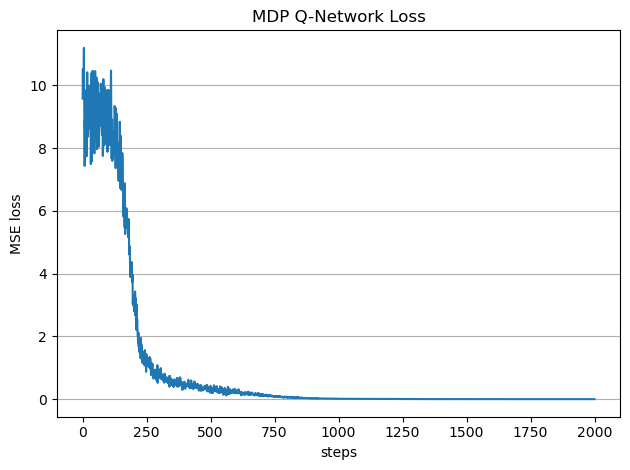

In [11]:
plt.plot(loss_list)
plt.xlabel("steps")
plt.ylabel("MSE loss")
plt.grid(axis="y")
plt.title("MDP Q-Network Loss")
plt.tight_layout()

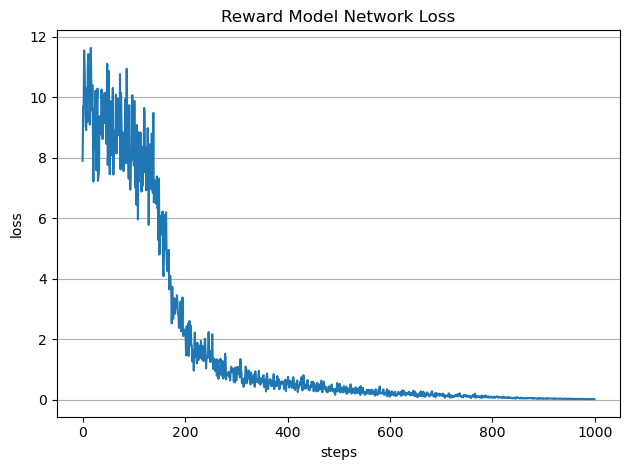

In [9]:
plt.plot(reward_loss)
plt.xlabel("steps")
plt.ylabel("loss")
plt.grid(axis="y")
plt.title("Reward Model Network Loss")
plt.tight_layout()

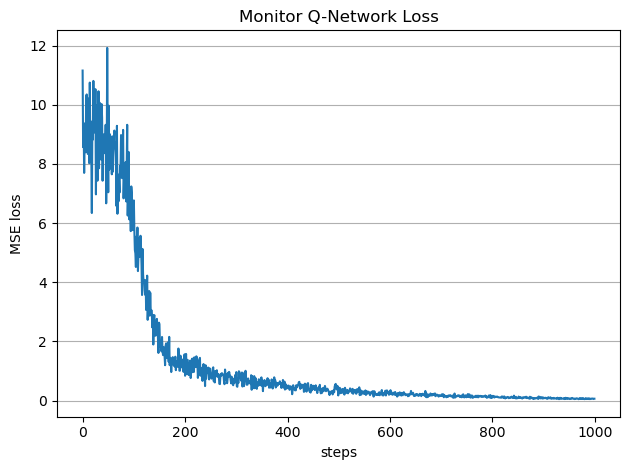

In [53]:
plt.plot(mon_loss_list)
plt.xlabel("steps")
plt.ylabel("MSE loss")
plt.grid(axis="y")
plt.title("Monitor Q-Network Loss")
plt.tight_layout()

In [15]:
indx_non = np.where(batch["mdp_reward"].cpu().numpy() > 0)[0]
indx_non

array([ 552,  632, 1001])

In [18]:
p = 632 #indx_non[0]
print(batch["mdp_obs"][p, 0])
policy_net(batch["mdp_obs"][p].unsqueeze(0)).cpu()

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')


tensor([[0.9387, 0.6744, 0.6694, 0.8224]], grad_fn=<ToCopyBackward0>)

In [18]:
log_dir = "../models/9_9/Penalty/q_learning/env_0.0/eps_1.0/q_lr_0.001/reward_lr_0.001/"
torch.save(policy_net, log_dir + "/q_network_best")

torch.Size([1, 2048])

In [7]:
new_samples = Transition(*zip(*samples))
print(np.where(np.array([r["mdp"] for r in new_samples.reward]) > 0)[0])
non_final_mask = torch.tensor(tuple(map(lambda s: s["mdp"] is not None, new_samples.next_obs)), dtype=torch.bool)
np.where(non_final_mask.numpy() != True)[0]

[  41   72  265  270  371  851 1170 1392 1519 1905 1967 1969 1995]


array([  41,   72,  265,  270,  371,  851, 1170, 1392, 1519, 1905, 1967,
       1969, 1995])

# Reward Model

In [22]:
reward_net = dqn_network(4, device)
reward_optimizer = torch.optim.Adam(reward_net.parameters(), lr=lr)
reward_loss_fun = torch.nn.MSELoss()
reward_loss = []
batch_process = []
sample_time = []
model_time = []

ep_start = time.time()
for ep in range(n_ep):
    start = time.time()
    samples = random.sample(list(mon_buffer), batch_size)
    sample_time.append(time.time() - start)
    
    start = time.time()
    batch = process_batch(samples)
    batch_process.append(time.time() - start)
    
    real_reward_idx = batch["real_reward_idx"]
    
    start = time.time()
    expected_reward = reward_net(batch["mdp_obs"][real_reward_idx]).gather(1, batch["mdp_action"][real_reward_idx])
    loss = reward_loss_fun(batch["mdp_reward"][real_reward_idx], expected_reward)

    reward_optimizer.zero_grad()
    loss.backward()
    reward_optimizer.step()
    model_time.append(time.time() - start)

    reward_loss.append(loss.item())
print("Total time = {:.3f}".format(time.time() - ep_start))

Total time = 46.773


### cut corners model on the GPU

In [23]:
print("Sampling time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(sample_time), 1e3 * np.std(sample_time)))
print("batch process time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_process), 1e3 * np.std(batch_process)))
print("R-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(model_time), 1e3 * np.std(model_time)))

Sampling time 5.69139 +- 0.347 ms
batch process time 5.32291 +- 0.985 ms
R-model time 12.08333 +- 38.862 ms


### model on the CPU 

In [6]:
print("Sampling time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(sample_time), 1e3 * np.std(sample_time)))
print("batch process time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_process), 1e3 * np.std(batch_process)))
print("R-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(model_time), 1e3 * np.std(model_time)))

Sampling time 5.70984 +- 0.553 ms
batch process time 24.56951 +- 0.962 ms
R-model time 33.73653 +- 1.939 ms


### model on the GPU

In [13]:
print("Sampling time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(sample_time), 1e3 * np.std(sample_time)))
print("batch process time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_process), 1e3 * np.std(batch_process)))
print("R-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(model_time), 1e3 * np.std(model_time)))

Sampling time 5.48363 +- 0.348 ms
batch process time 28.29663 +- 1.484 ms
R-model time 4.60530 +- 6.121 ms


In [11]:
(33.7 + 4.8)*n_ep/1000

77.0

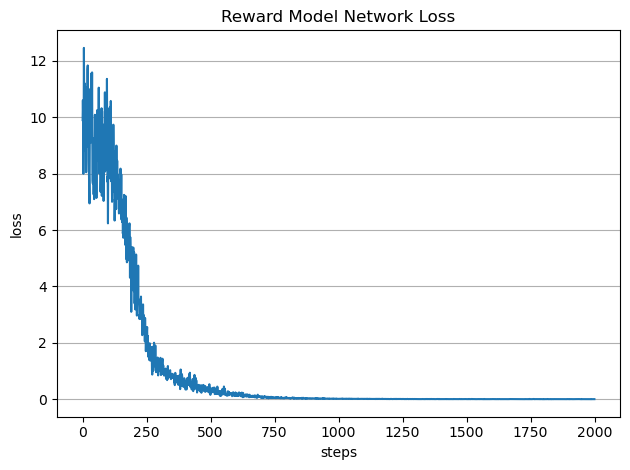

In [24]:
plt.plot(reward_loss)
plt.xlabel("steps")
plt.ylabel("loss")
plt.grid(axis="y")
plt.title("Reward Model Network Loss")
plt.tight_layout()

In [8]:
log_dir = "../models/9_9/Penalty/q_learning/env_0.0/eps_1.0/q_lr_0.001/reward_lr_0.001/"
# reward_net = torch.load(log_dir + "/reward_network_best")

In [26]:
indx = np.where(batch["mdp_reward"].squeeze(1).cpu().numpy() > 0)[0]
indx

array([896])

In [28]:
point = 96#indx[0]
print(batch["mdp_obs"][point, 0])
print("action {}, reward {}".format(batch["mdp_action"][point, 0].item(), batch["mdp_reward"][point, 0].item()))
np.round(reward_net(batch["mdp_obs"][point].unsqueeze(0)).detach().cpu().numpy()[0], 3)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')
action 0, reward -10.0


array([-9.995e+00,  3.000e-03,  1.100e-02,  5.000e-03], dtype=float32)

In [32]:
1000 * (3090/4e5)

7.7250000000000005

In [34]:
(8 * 4e5) / 1000

3200.0